# data load

In [1]:
from pathlib import Path
import pandas as pd
import numpy as np

from sklearn.model_selection import train_test_split, ParameterGrid
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score

from sklearn.linear_model import LogisticRegression
from sklearn.svm import SVC
from imblearn.ensemble import BalancedRandomForestClassifier
from sklearn.ensemble import RandomForestClassifier

from imblearn.combine import SMOTETomek
from imblearn.ensemble import EasyEnsembleClassifier



In [2]:
# 현재 노트북 위치
BASE_DIR = Path().resolve()

# 프로젝트 루트 (notebooks의 상위 폴더)
PROJECT_ROOT = BASE_DIR.parent

# data 폴더
DATA_DIR = PROJECT_ROOT / "data"

# data 파일
path1 = DATA_DIR / "all_data_v1_update.csv"
trade_area_path = DATA_DIR / "서울시 상권분석서비스(길단위인구-상권).csv"

# data load
df = pd.read_csv(path1, encoding="utf-8")
trade_area_info = pd.read_csv(trade_area_path, encoding="cp949")

# 파생변수 생성

In [3]:
# -----------------------
# 1) 성별 컬럼 정의
# -----------------------
female_cols = [c for c in df.columns if c.startswith("여성")]
male_cols   = [c for c in df.columns if c.startswith("남성")]

# -----------------------
# 2) 행 단위 성별 합계
# -----------------------
df["여성_합계"] = df[female_cols].sum(axis=1)
df["남성_합계"] = df[male_cols].sum(axis=1)


In [4]:
# -----------------------
# 1) 연령대 컬럼 정의
# -----------------------
age_cols = {
    "20대": [c for c in df.columns if "20대" in c],
    "30대": [c for c in df.columns if "30대" in c],
    "40대": [c for c in df.columns if "40대" in c],
    "50대": [c for c in df.columns if "50대" in c],
    "60대": [c for c in df.columns if "60대" in c],

}

# -----------------------
# 2) 행(row) 단위 연령대 합계
# -----------------------
for age, cols in age_cols.items():
    df[f"{age}_합계"] = df[cols].sum(axis=1)

In [5]:
df["배달여부"] = (
    df.groupby("가맹점구분번호")["배달매출금액 비율"]
      .transform(lambda x: (x != 0).any())
      .astype(int)
)

# 분기별 요약변수 생성

In [6]:
# 분기 컬럼 생성
df["기준년월"] = pd.to_datetime(df["기준년월"])
df["연도"] = df["기준년월"].dt.year
df["분기"] = df["기준년월"].dt.quarter

In [7]:
target_cols = ['가맹점 운영개월수 구간','배달여부', '배달매출금액 비율','객단가 구간', '동일 업종 내 해지 가맹점 비중',
               '여성_합계', '남성_합계',
               '20대_합계', '30대_합계', '40대_합계', '50대_합계','60대_합계',]


In [8]:
# 상점×분기 압축 (평균/표준편차)
summary_df = (
    df.groupby(["가맹점구분번호", "연도", "분기"], dropna=False)[target_cols]
      .agg(["mean", "std"])
)
# 컬럼명 깔끔하게: (컬럼, mean/std) → "컬럼_mean" 형태
summary_df.columns = [f"{col}_{stat}" for col, stat in summary_df.columns]
summary_df = summary_df.reset_index()

# 선택: 표준편차가 NaN(분기 데이터 1개뿐이면 std가 NaN)인 경우 0으로
std_cols = [c for c in summary_df.columns if c.endswith("_std")]
summary_df[std_cols] = summary_df[std_cols].fillna(0)


In [9]:
summary_df.head()

,가맹점구분번호,연도,분기,가맹점 운영개월수 구간_mean,가맹점 운영개월수 구간_std,배달여부_mean,배달여부_std,배달매출금액 비율_mean,배달매출금액 비율_std,객단가 구간_mean,...,20대_합계_mean,20대_합계_std,30대_합계_mean,30대_합계_std,40대_합계_mean,40대_합계_std,50대_합계_mean,50대_합계_std,60대_합계_mean,60대_합계_std
0,000F03E44A,2023,1,5.000000,0.00000,1.0,0.0,69.283333,0.0,5.333333,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,100.000000,0.000000,0.000000,0.00000
1,000F03E44A,2023,2,5.000000,0.00000,1.0,0.0,69.283333,0.0,5.000000,...,0.000000,0.000000,63.900000,12.733028,0.000000,0.000000,36.100000,12.733028,0.000000,0.00000
2,000F03E44A,2023,3,5.000000,0.00000,1.0,0.0,69.283333,0.0,5.666667,...,0.000000,0.000000,70.000000,8.660254,0.000000,0.000000,30.000000,8.660254,0.000000,0.00000
3,000F03E44A,2023,4,4.333333,0.57735,1.0,0.0,69.283333,0.0,6.000000,...,11.133333,9.641749,53.333333,5.773503,0.000000,0.000000,35.533333,3.868247,0.000000,0.00000
4,000F03E44A,2024,1,4.000000,0.00000,1.0,0.0,69.283333,0.0,5.333333,...,23.833333,8.247626,45.766667,16.755994,3.033333,5.253887,15.266667,5.589574,12.133333,21.01555


In [10]:
## p-value < 0.05인 변수만 선택
selected_cols = [
    '가맹점구분번호', '연도', '분기',
    '남성_합계_mean',
    '여성_합계_mean',
    '가맹점 운영개월수 구간_mean',
    '배달매출금액 비율_std',
    '60대_합계_mean',
    '20대_합계_mean',
    '배달매출금액 비율_mean',
    '배달여부_mean',
    '30대_합계_mean',
    '50대_합계_mean',
    '객단가 구간_mean',
    '60대_합계_std',
    '동일 업종 내 해지 가맹점 비중_std',
    '객단가 구간_std'
]
summary_df = summary_df[selected_cols]


In [11]:
df_first = (
    df[["가맹점구분번호", "폐업여부",'상권']]
    .drop_duplicates(subset="가맹점구분번호", keep="first")
)

final_df = summary_df.merge(
    df_first,
    on="가맹점구분번호",
    how="left"
)


# 파생변수 - 상권 활성화 지수

## 상권_유동인구_수 

In [12]:
# 0) 기준 분기 & 성동구 상권 목록
target_quarters = [20231, 20232, 20233, 20234, 20241, 20242, 20243, 20244]
seongdong_area = df["상권"].unique()

# 1) 외부 유동인구 데이터 전처리 (필터링 + 연도/분기 분리 + 컬럼 정리)
trade_area_population = (
    trade_area_info.loc[
        trade_area_info["기준_년분기_코드"].isin(target_quarters)
        & trade_area_info["상권_코드_명"].isin(seongdong_area),
        ["상권_코드_명", "기준_년분기_코드", "총_유동인구_수"]
    ]
    .assign(
        연도=lambda x: x["기준_년분기_코드"].astype(str).str[:4].astype(int),
        분기=lambda x: x["기준_년분기_코드"].astype(str).str[4:].astype(int),
        상권=lambda x: x["상권_코드_명"]
    )
    .drop(columns=["상권_코드_명", "기준_년분기_코드"])
    .rename(columns={"총_유동인구_수": "상권_유동인구_수"})
)

## 상권_소비력

In [13]:
# 1) 상권별 평균값 집계
area_agg = (
    df.groupby("상권", as_index=False)
        .agg({
            "매출금액 구간": "mean",
            "유니크 고객 수 구간": "mean",
        })
)

# # 2) 순위/구간 점수화
#    - 매출금액, 고객 수 구간: 1~6 → 0~100 선형 변환
area_agg["매출_점수"] = (6 - area_agg["매출금액 구간"]) / 5 * 100
area_agg["고객수_점수"] = (6 - area_agg["유니크 고객 수 구간"]) / 5 * 100


# 3) 상권 소비력 계산
#    - 매출, 고객 수, 업종 내 순위 점수 평균

sel_col = ["매출_점수", "고객수_점수"] 
area_agg["상권_소비력"] = area_agg[sel_col].mean(axis=1)
area_active= trade_area_population.merge(area_agg[["상권","상권_소비력"]])

## 상권_활성화지수

In [14]:
# 1) 표준화
scaler = StandardScaler()
scaled = scaler.fit_transform(area_active[["상권_유동인구_수", "상권_소비력"]])

# 2) 음수값 처리 및 기하평균 계산
scaled_shifted = scaled - scaled.min(axis=0) + 1e-9
area_active["상권_활성화지수"] = np.sqrt(scaled_shifted[:, 0] * scaled_shifted[:, 1])
area_active = area_active.drop(columns=["상권_유동인구_수", "상권_소비력"])

In [15]:
# 2) 병합 (상권/연도/분기 기준)
merged_df = final_df.merge(
    area_active,
    on=["상권", "연도", "분기"],
    how="left"
)
# 결측치 처리
merged_df["상권_활성화지수"] = merged_df["상권_활성화지수"].fillna(
    merged_df["상권_활성화지수"].mean()
)
merged_df = merged_df.drop(columns=["상권"])

# 
final_df = merged_df.copy()


# ex) 2024년 1분기 폐업 예측

In [16]:
df_2023_q1 = final_df[(final_df["연도"] == 2024) & (final_df["분기"] == 1)]

X = df_2023_q1.drop(columns=['가맹점구분번호','연도','분기','폐업여부'])
y = df_2023_q1["폐업여부"].astype(int)

X_train, X_test, y_train, y_test = train_test_split(X, y, stratify=y, random_state=42)

#  표준화
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

# # SMOTE 적용
# smote = SMOTETomek(random_state=42)
# X_train_smote, y_train_smote = smote.fit_resample(X_train_scaled, y_train)

In [19]:
# 모델 정의
models = {
    'LogisticRegression': LogisticRegression(random_state=42, max_iter=1000, class_weight="balanced"),
    'SVM': SVC(random_state=42, class_weight="balanced"),
    'EasyEnsembleClassifier': EasyEnsembleClassifier(random_state=47, n_jobs=1)
}

# 결과 저장
results = {'Model': [], 'Accuracy': [], 'Precision': [], 'Recall': [], 'F1': []}

# 모델별 학습 및 평가
for model_name, model in models.items():
    model.fit(X_train_scaled, y_train)
    y_pred = model.predict(X_test_scaled)

    results['Model'].append(model_name)
    results['Accuracy'].append(accuracy_score(y_test, y_pred))
    results['Precision'].append(precision_score(y_test, y_pred))
    results['Recall'].append(recall_score(y_test, y_pred))
    results['F1'].append(f1_score(y_test, y_pred))

# 결과를 DataFrame으로 변환
results_df = pd.DataFrame(results)

In [18]:
import sys, locale
print("defaultencoding:", sys.getdefaultencoding())
print("filesystemencoding:", sys.getfilesystemencoding())
print("stdout encoding:", sys.stdout.encoding)
print("preferredencoding:", locale.getpreferredencoding(False))


defaultencoding: utf-8
filesystemencoding: utf-8
stdout encoding: UTF-8
preferredencoding: cp949


In [20]:
results_df

,Model,Accuracy,Precision,Recall,F1
0,LogisticRegression,0.623644,0.031519,0.55,0.059621
1,SVM,0.777657,0.010582,0.10,0.019139
2,EasyEnsembleClassifier,0.542299,0.028169,0.60,0.053812


# Baseline_LogisticRegression

In [21]:
# 2) 앙상블 평가용 공통 test set 1번만 분리
X_all = final_df.drop(columns=['가맹점구분번호','연도','분기','폐업여부'])
y_all = final_df["폐업여부"].astype(int)

X_train_all, X_test, y_train_all, y_test = train_test_split(
    X_all, y_all, stratify=y_all, random_state=42, test_size=0.2
)

test_idx = X_test.index  # 누수 방지용(분기 train에서 test행 제외)

# 3) 8개(연도×분기) 모델 학습
models = []  # (scaler, model) 저장

for year in [2023, 2024]:
    for q in [1, 2, 3, 4]:
        df_q = final_df[(final_df["연도"] == year) & (final_df["분기"] == q)].copy()

        # 분기 데이터에서 test에 들어간 행 제거(누수 방지)
        df_q = df_q.drop(index=test_idx, errors="ignore")

        # X,y 만들기
        X_q = df_q.drop(columns=['가맹점구분번호','연도','분기','폐업여부'])
        y_q = df_q["폐업여부"].astype(int)

        # 학습 불가(클래스 한쪽뿐/데이터 너무 적음)면 스킵
        if y_q.nunique() < 2 or len(y_q) < 30:
            print(f"[SKIP] {year} Q{q} (데이터/클래스 부족)")
            continue

        # 스케일링(분기 train 기준)
        scaler = StandardScaler()
        X_q_scaled = scaler.fit_transform(X_q)

        # SMOTETomek(분기 train에만)
        smt = SMOTETomek(random_state=42)
        X_q_bal, y_q_bal = smt.fit_resample(X_q_scaled, y_q)

        # 모델 학습
        model = LogisticRegression(random_state=42, max_iter=1000)
        model.fit(X_q_bal, y_q_bal)

        models.append((scaler, model))
        print(f"[OK] {year} Q{q} model trained")

print("학습된 분기 모델 수:", len(models))

# 4) 앙상블(soft voting): 분기 모델들의 예측확률 평균
probas = []
for scaler, model in models:
    X_test_scaled = scaler.transform(X_test)
    probas.append(model.predict_proba(X_test_scaled)[:, 1])

avg_proba = np.mean(np.vstack(probas), axis=0)
y_pred = (avg_proba >= 0.5).astype(int)

# 5) 평가
results_df = pd.DataFrame([{
    "Model": f"Quarter Ensemble ({len(models)} models)",
    "Accuracy": accuracy_score(y_test, y_pred),
    "Precision": precision_score(y_test, y_pred, zero_division=0),
    "Recall": recall_score(y_test, y_pred, zero_division=0),
    "F1": f1_score(y_test, y_pred, zero_division=0)
}])

results_df


[OK] 2023 Q1 model trained
[OK] 2023 Q2 model trained
[OK] 2023 Q3 model trained
[OK] 2023 Q4 model trained
[OK] 2024 Q1 model trained
[OK] 2024 Q2 model trained
[OK] 2024 Q3 model trained
[OK] 2024 Q4 model trained
학습된 분기 모델 수: 8


,Model,Accuracy,Precision,Recall,F1
0,Quarter Ensemble (8 models),0.581395,0.027414,0.558333,0.052262


# VIF(분산 팽창 계수)

In [ ]:
from statsmodels.tools.tools import add_constant
from statsmodels.stats.outliers_influence import variance_inflation_factor

#final_df

# def feature_selection(create_features_result):
  #VIF
  # 변수 제거 전
final_df = final_df.rename(columns={"배달여부_mean": "배달여부",})
X_const = add_constant(final_df.drop(columns=['가맹점구분번호','폐업여부']))
X_const = X_const.astype(float)
vif = pd.DataFrame()
vif["Feature"] = X_const.columns
vif["VIF"] = [variance_inflation_factor(X_const.values, i) for i in range(X_const.shape[1])]
print("\n--- 변수 제거 전 분산팽창계수(VIF) ---")
vif



--- 변수 제거 전 분산팽창계수(VIF) ---
                  Feature           VIF
0                   const  1.664045e+07
1                      연도  1.009163e+00
2                      분기  1.031281e+00
3              남성_합계_mean  1.233802e+01
4              여성_합계_mean  1.222399e+01
5       가맹점 운영개월수 구간_mean  1.195702e+00
6           배달매출금액 비율_std  1.476184e+00
7             60대_합계_mean  3.597309e+00
8             20대_합계_mean  3.163143e+00
9          배달매출금액 비율_mean  1.686960e+00
10              배달여부_mean  1.864788e+00
11            30대_합계_mean  2.961377e+00
12            50대_합계_mean  2.631010e+00
13            객단가 구간_mean  1.122404e+00
14             60대_합계_std  1.144095e+00
15  동일 업종 내 해지 가맹점 비중_std  1.037138e+00
16             객단가 구간_std  1.123764e+00
17               상권_활성화지수  1.095909e+00


In [ ]:
  # 변수 제거 후
X_const = add_constant(final_df.drop(columns=['가맹점구분번호','폐업여부','남성_합계_mean','연도','분기']))
X_const = X_const.astype(float)
vif = pd.DataFrame()
vif["Feature"] = X_const.columns
vif["VIF"] = [variance_inflation_factor(X_const.values, i) for i in range(X_const.shape[1])]
print("\n--- 변수 제거 후 분산팽창계수(VIF) ---")
vif


--- 변수 제거 후 분산팽창계수(VIF) ---
                  Feature        VIF
0                   const  73.704273
1              여성_합계_mean   1.162882
2       가맹점 운영개월수 구간_mean   1.187098
3           배달매출금액 비율_std   1.475758
4             60대_합계_mean   3.123444
5             20대_합계_mean   2.765296
6          배달매출금액 비율_mean   1.685775
7               배달여부_mean   1.861050
8             30대_합계_mean   2.525399
9             50대_합계_mean   2.232187
10            객단가 구간_mean   1.106041
11             60대_합계_std   1.141822
12  동일 업종 내 해지 가맹점 비중_std   1.002902
13             객단가 구간_std   1.122281
14               상권_활성화지수   1.095773


In [ ]:
# 최종 선택 변수
final_df = final_df[['가맹점구분번호', '연도', '분기', '여성_합계_mean', '가맹점 운영개월수 구간_mean',
       '배달매출금액 비율_std', '60대_합계_mean', '20대_합계_mean', '배달매출금액 비율_mean',
       '배달여부', '30대_합계_mean', '50대_합계_mean', '객단가 구간_mean', '60대_합계_std',
       '동일 업종 내 해지 가맹점 비중_std', '객단가 구간_std', '폐업여부', '상권_활성화지수']]


# 여러 모델 비교 

In [31]:
# -------------------------------------------------
# 0) 공통 테스트셋 1번만 분리
# -------------------------------------------------
df = final_df.copy()

X_all = df.drop(columns=['가맹점구분번호','연도','분기','폐업여부'])
y_all = df["폐업여부"].astype(int)

X_train_all, X_test, y_train_all, y_test = train_test_split(
    X_all, y_all, stratify=y_all, random_state=42, test_size=0.2
)
test_idx = X_test.index   # 누수 방지: 분기 train에서 test 행 제거


# -------------------------------------------------
# 1) 비교할 모델 후보(이름, 모델객체, SMOTE쓸지)
# -------------------------------------------------
candidates = [
    ("LogReg + SMOTETomek",
     LogisticRegression(random_state=42, max_iter=1000, class_weight="balanced"),
     True),

    ("SVM + SMOTETomek",
     SVC(random_state=42, class_weight="balanced", probability=True),
     True),

    ("BalancedRandomForest",
     BalancedRandomForestClassifier(random_state=42, n_estimators=300, n_jobs=1),
     False),

    ("EasyEnsemble",
     EasyEnsembleClassifier(random_state=47, n_jobs=1),
     False),

    ("RandomForest",
     RandomForestClassifier(random_state=42, n_estimators=300, class_weight="balanced", n_jobs=1),
     False),
]


# -------------------------------------------------
# 2) 후보 모델 1개에 대해 "8개 분기 모델 앙상블" 평가하는 함수
# -------------------------------------------------
def eval_quarter_ensemble(base_model, use_smote, min_rows=30):
    trained = []  # (scaler, model)

    for year in [2023, 2024]:
        for q in [1, 2, 3, 4]:
            df_q = df[(df["연도"] == year) & (df["분기"] == q)].copy()
            df_q = df_q.drop(index=test_idx, errors="ignore")  # 누수 방지

            X_q = df_q.drop(columns=['가맹점구분번호','연도','분기','폐업여부'])
            y_q = df_q["폐업여부"].astype(int)

            # 학습 불가 방지(클래스 1개면 SMOTE도 불가)
            if y_q.nunique() < 2 or len(y_q) < min_rows:
                continue

            scaler = StandardScaler()
            X_q_scaled = scaler.fit_transform(X_q)

            if use_smote:
                smt = SMOTETomek(random_state=42)
                X_q_scaled, y_q = smt.fit_resample(X_q_scaled, y_q)

            # 모델은 분기마다 새로 생성해야 함(객체 재사용하면 덮어씀)
            model = type(base_model)(**base_model.get_params())
            model.fit(X_q_scaled, y_q)

            trained.append((scaler, model))

    if len(trained) == 0:
        return None

    # soft voting: 예측확률 평균
    probas = []
    for scaler, model in trained:
        X_test_scaled = scaler.transform(X_test)
        probas.append(model.predict_proba(X_test_scaled)[:, 1])

    avg_proba = np.mean(np.vstack(probas), axis=0)
    y_pred = (avg_proba >= 0.5).astype(int)

    return {
        "n_models_used": len(trained),
        "Accuracy": accuracy_score(y_test, y_pred),
        "Precision": precision_score(y_test, y_pred, zero_division=0),
        "Recall": recall_score(y_test, y_pred, zero_division=0),
        "F1": f1_score(y_test, y_pred, zero_division=0),
    }


# -------------------------------------------------
# 3) 후보별로 돌려서 결과 비교
# -------------------------------------------------
rows = []
for name, model, use_smote in candidates:
    out = eval_quarter_ensemble(model, use_smote=use_smote, min_rows=30)
    if out is None:
        rows.append({"Model": name, "n_models_used": 0, "Accuracy": np.nan, "Precision": np.nan, "Recall": np.nan, "F1": np.nan})
    else:
        rows.append({"Model": name, **out})

results_df = pd.DataFrame(rows).sort_values("F1", ascending=False)
results_df


,Model,n_models_used,Accuracy,Precision,Recall,F1
2,BalancedRandomForest,8,0.850646,0.060071,0.425000,0.105263
1,SVM + SMOTETomek,8,0.960724,0.097015,0.108333,0.102362
3,EasyEnsemble,8,0.491645,0.028952,0.725000,0.055680
0,LogReg + SMOTETomek,8,0.580017,0.026165,0.533333,0.049883
4,RandomForest,8,0.979328,0.000000,0.000000,0.000000


## 여러 모델 시각화 비교

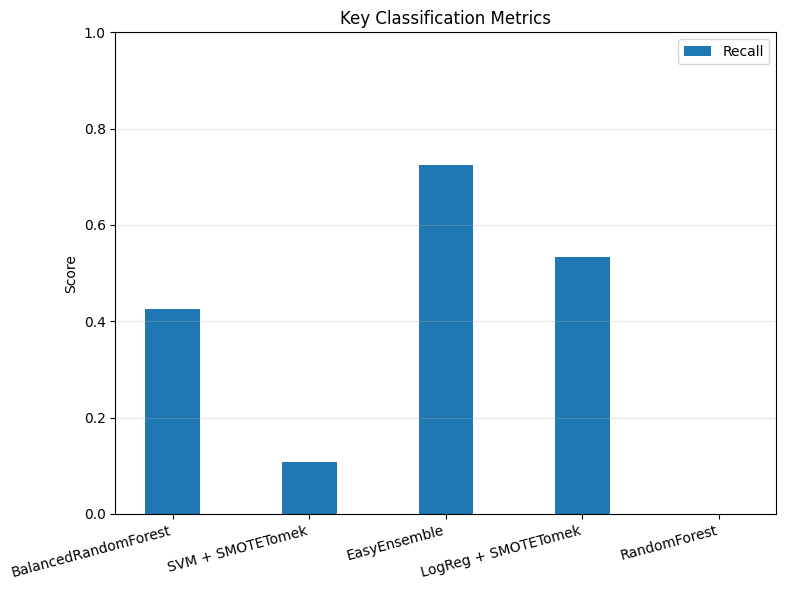

In [35]:
import numpy as np
import matplotlib.pyplot as plt

# results_df: Model, Accuracy, Precision, Recall, F1 컬럼이 있다고 가정
metrics = ["Recall"]

# 정렬 유지(지금은 F1 내림차순으로 되어있으니 그대로 사용)
plot_df = results_df.copy()

x = np.arange(len(plot_df["Model"]))
width = 0.4  # 막대 폭(4개라서 조금 얇게)

plt.figure(figsize=(8, 6))

for i, m in enumerate(metrics):
    plt.bar(x + (i - (len(metrics)-1)/2) * width, plot_df[m].values, width, label=m)

plt.title("Key Classification Metrics")
plt.ylabel("Score")
plt.ylim(0, 1.0)

plt.xticks(x, plot_df["Model"], rotation=15, ha="right")

plt.legend()
plt.grid(axis="y", alpha=0.3)
plt.tight_layout()
plt.show()


# 최종모델 그리드 서치 - BalancedRandomForest

In [ ]:
# 1) BalancedRF 파라미터 그리드
brf_param_grid = {
    "n_estimators": [300],          
    "max_depth": [None, 12],        
    "min_samples_leaf": [1, 2],     
    "max_features": ["sqrt"],       
    "bootstrap": [False, True],     
}
# 2) 그리드 탐색 실행
grid_rows = []
for params in ParameterGrid(brf_param_grid):
    brf = BalancedRandomForestClassifier(
        random_state=42,
        n_jobs=-1,
        **params
    )
    out = eval_quarter_ensemble(brf, use_smote=False, min_rows=30)

    if out is None:
        grid_rows.append({"Model": "BalancedRandomForest", **params,
                          "n_models_used": 0, "Accuracy": np.nan, "Precision": np.nan, "Recall": np.nan, "F1": np.nan})
    else:
        grid_rows.append({"Model": "BalancedRandomForest", **params, **out})

brf_grid_results = (
    pd.DataFrame(grid_rows)
    .sort_values(["F1", "Recall", "Precision"], ascending=False)
    .reset_index(drop=True)
)

# 3) 결과 확인
display(brf_grid_results.head(20))

best_brf = brf_grid_results.iloc[0]
print("\n=== BEST BalancedRandomForest params ===")
print(best_brf)

# (옵션) 베스트 파라미터 dict만 뽑기
best_brf_params = {k: best_brf[k] for k in brf_param_grid.keys()}
print("\nBest params dict:", best_brf_params)

,Model,bootstrap,max_depth,max_features,min_samples_leaf,n_estimators,n_models_used,Accuracy,Precision,Recall,F1
0,BalancedRandomForest,False,NaN,sqrt,1,300,8,0.850646,0.060071,0.425000,0.105263
1,BalancedRandomForest,False,12.0,sqrt,1,300,8,0.848062,0.058005,0.416667,0.101833
2,BalancedRandomForest,True,NaN,sqrt,1,300,8,0.791731,0.051113,0.516667,0.093023
3,BalancedRandomForest,False,NaN,sqrt,2,300,8,0.834970,0.052350,0.408333,0.092803
4,BalancedRandomForest,True,12.0,sqrt,1,300,8,0.791214,0.050247,0.508333,0.091454
5,BalancedRandomForest,False,12.0,sqrt,2,300,8,0.834281,0.051173,0.400000,0.090737
6,BalancedRandomForest,True,12.0,sqrt,2,300,8,0.776572,0.044857,0.483333,0.082095
7,BalancedRandomForest,True,NaN,sqrt,2,300,8,0.776227,0.044084,0.475000,0.080679



=== BEST BalancedRandomForest params ===
Model               BalancedRandomForest
bootstrap                          False
max_depth                            NaN
max_features                        sqrt
min_samples_leaf                       1
n_estimators                         300
n_models_used                          8
Accuracy                        0.850646
Precision                       0.060071
Recall                             0.425
F1                              0.105263
Name: 0, dtype: object

Best params dict: {'n_estimators': np.int64(300), 'max_depth': np.float64(nan), 'min_samples_leaf': np.int64(1), 'max_features': 'sqrt', 'bootstrap': np.False_}
